# MongoDB Exploratory Data Analysis (EDA) Case Study

---

## Student Information

| Particular | Details |
|------------|---------|
| Student Name | __________________________ |
| Roll Number | __________________________ |
| Branch | CSE-AI |
| Year & Semester | IV Year & I Semester |
| Subject | NoSQL Databases |
| Case Study Title | Exploratory Data Analysis (EDA) using MongoDB |
| Faculty Name | Mr B A V L Sainadh |
| Date | __________________________ |

---

# Dataset Information

| Attribute | Details |
|-----------|---------|
| Dataset Name | sample_supplies |
| Database Name | sample_supplies |
| Collection Name | sales |
| Business Domain | Retail Sales |
| Data Source | MongoDB Sample Dataset |

## Dataset Description

The **sample_supplies** dataset contains retail sales transactions of an office supplies company. Each document represents a single sales transaction and includes customer information, purchased products, store location, purchase method, and transaction date.

The dataset follows MongoDB's document-oriented data model, where related information is stored together in a single document using embedded documents and arrays. This structure enables efficient storage and retrieval of semi-structured business data.

# Case Study Overview

Retail organizations generate thousands of sales transactions every day. Analyzing these transactions helps businesses understand customer behavior, evaluate store performance, identify sales trends, and make informed business decisions.

In this case study, MongoDB is used as the primary data source for performing **Exploratory Data Analysis (EDA)**. Using **PyMongo**, we will query the sales data, analyze key business metrics, and visualize the results to gain meaningful business insights.

This notebook demonstrates a typical data analysis workflow using MongoDB and serves as a sample EDA case study. Students can use the same methodology to analyze different MongoDB datasets in future assignments.

# Business Objectives

The primary objectives of this case study are to:

- Understand the structure of the MongoDB dataset.
- Explore the sales transaction data using PyMongo.
- Perform exploratory data analysis (EDA) on business data.
- Answer business questions using MongoDB queries.
- Visualize analytical results using Python.
- Interpret the findings and derive meaningful business insights.
- Provide actionable recommendations based on the analysis.

# Case Study Workflow

The case study follows the standard Exploratory Data Analysis (EDA) workflow used in data analytics projects.

1. Environment Setup
2. Understand the Dataset
3. Perform Exploratory Data Analysis
4. Visualize Results
5. Generate Business Insights
6. Provide Actionable Recommendations

By following this workflow, raw business data is transformed into meaningful information that supports effective decision-making.

# Environment Setup

Before starting the exploratory data analysis, we need to prepare the Python environment and establish a connection with the local MongoDB Community Server.

This section imports the required Python libraries, configures the notebook for better readability, and connects to the MongoDB database containing the business dataset.

## Import Required Libraries

The following libraries are used throughout this case study:

- **PyMongo** – Connect to MongoDB and execute queries.
- **Pandas** – Data manipulation and tabular analysis.
- **NumPy** – Numerical operations.
- **Matplotlib** – Data visualization.
- **Seaborn** – Statistical data visualization.
- **pprint** – Display MongoDB documents in a readable format.

In [13]:
from pymongo import MongoClient

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pprint import pprint

## Configure Notebook Settings

Configure display options to improve the readability of tables and visualizations throughout the notebook.

In [14]:
# Pandas Display Settings
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

# Visualization Settings
plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 120

## Connect to MongoDB

Create a connection to the local MongoDB Community Server.

In [15]:
client = MongoClient("mongodb://localhost:27017")

# Dataset Setup

Before starting this case study, the **sample_supplies** dataset must be imported into your local MongoDB Community Server.

This is a one-time setup process. Once imported, the dataset remains available in your local MongoDB instance until it is deleted.

## Step 1: Download the Dataset

The dataset used in this case study is available from the following GitHub repository:

https://github.com/neelabalan/mongodb-sample-dataset

Download or clone the repository and locate the following file:

```

mongodb-sample-dataset/
└── sample_supplies/
    └── sales.json

```

This file contains the sales transaction data used throughout this notebook.

## Step 2: Import the Dataset into MongoDB

Open **Command Prompt** or **PowerShell** and execute the following command.

Replace the file path with the location of **sales.json** on your computer.

In [ ]:
!mongoimport --db sample_supplies --collection sales --file "C:\path\to\sales.json..................(Add the correct path to your sales.json file here).................."

In [ ]:
!mongoimport --db sample_supplies --collection sales --file "C:\path\to\sales.json"

If the import is successful, MongoDB will create:

- **Database:** `sample_supplies`
- **Collection:** `sales`

The dataset is now ready for analysis using PyMongo.

## Connect to the Database and Collection

Connect to the **sample_supplies** database and access the **sales** collection, which will be used throughout this case study.

In [16]:
db = client["sample_supplies"]

sales = db["sales"]

## Verify the Connection

Before beginning the analysis, verify that the collection is accessible and contains data.

In [17]:
print(f"Database   : {db.name}")
print(f"Collection : {sales.name}")
print(f"Documents  : {sales.count_documents({}):,}")

Database   : sample_supplies
Collection : sales
Documents  : 5,000


# Understanding the Dataset

Before performing exploratory data analysis, it is important to understand the structure of the dataset.

The **sales** collection stores retail sales transactions. Each document represents a single transaction and contains information about:

- Customer details
- Purchased items
- Store location
- Purchase method
- Transaction date
- Coupon usage

Understanding the document structure helps us write accurate queries and perform meaningful business analysis.

## Dataset Overview

Let's begin by examining some basic information about the dataset.

In [18]:
print(f"Database Name   : {db.name}")
print(f"Collection Name : {sales.name}")
print(f"Total Documents : {sales.count_documents({}):,}")

Database Name   : sample_supplies
Collection Name : sales
Total Documents : 5,000


## Display a Sample Document

Viewing a sample document helps us understand how information is organized within the collection.

In [19]:
document = sales.find_one()

pprint(document)

{'_id': ObjectId('5bd761dcae323e45a93ccfed'),
 'couponUsed': False,
 'customer': {'age': 44,
              'email': 'owtar@pu.cd',
              'gender': 'M',
              'satisfaction': 2},
 'items': [{'name': 'binder',
            'price': Decimal128('13.44'),
            'quantity': 8,
            'tags': ['school', 'general', 'organization']},
           {'name': 'binder',
            'price': Decimal128('16.66'),
            'quantity': 10,
            'tags': ['school', 'general', 'organization']}],
 'purchaseMethod': 'In store',
 'saleDate': datetime.datetime(2015, 9, 2, 16, 11, 59, 565000),
 'storeLocation': 'London'}


## Top-Level Fields

The following code displays the top-level fields available in a sales document.

In [20]:
list(document.keys())

['_id',
 'saleDate',
 'items',
 'storeLocation',
 'customer',
 'couponUsed',
 'purchaseMethod']

## Understanding the Document Structure

The sales document contains several important fields.

| Field | Description |
|--------|-------------|
| `_id` | Unique identifier of the transaction |
| `saleDate` | Date and time of the transaction |
| `storeLocation` | Store where the purchase was made |
| `customer` | Customer information stored as an embedded document |
| `items` | List of purchased products stored as an array |
| `purchaseMethod` | Purchase channel (Online, In-store, Phone) |
| `couponUsed` | Indicates whether a coupon was applied |

## Customer Information

Customer information is stored as an **embedded document**.

In [21]:
pprint(document["customer"])

{'age': 44, 'email': 'owtar@pu.cd', 'gender': 'M', 'satisfaction': 2}


## Purchased Items

Each transaction may contain one or more purchased products.

These products are stored as an **array of embedded documents**.

In [22]:
pprint(document["items"])

[{'name': 'binder',
  'price': Decimal128('13.44'),
  'quantity': 8,
  'tags': ['school', 'general', 'organization']},
 {'name': 'binder',
  'price': Decimal128('16.66'),
  'quantity': 10,
  'tags': ['school', 'general', 'organization']}]


## Data Types

The following code displays the data type of each top-level field.

In [23]:
for field, value in document.items():
    print(f"{field:<20} {type(value).__name__}")

_id                  ObjectId
saleDate             datetime
items                list
storeLocation        str
customer             dict
couponUsed           bool
purchaseMethod       str


## Dataset Summary

From the above exploration, we can observe that:

- Each document represents a single sales transaction.
- Customer information is stored as an embedded document.
- Purchased products are stored as an array of embedded documents.
- The dataset contains both structured and semi-structured data, making it suitable for MongoDB's document-oriented model.

Having understood the dataset structure, we are now ready to perform exploratory data analysis by answering business questions and deriving meaningful insights from the data.

# Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is the process of examining a dataset to understand its characteristics, identify patterns, and generate meaningful insights before performing advanced analysis or predictive modeling.

In this section, we will answer three business questions with increasing complexity:

1. **Simple Analysis** – Basic document query
2. **Intermediate Analysis** – Aggregation Framework
3. **Advanced Analysis** – Multi-stage Aggregation Framework

Each analysis follows the same structure:

- Question
- Code for Query
- Code for Visualization
- Business Insight

# Question 1: What is the total number of sales transactions recorded in the dataset?

## Business Objective

Before performing detailed business analysis, management wants to determine the total number of sales transactions available in the dataset.

This provides an overall measure of business activity and serves as a baseline Key Performance Indicator (KPI) for subsequent analyses.

## Code for Query

In [24]:
total_transactions = sales.count_documents({})

print(f"Total Sales Transactions: {total_transactions:,}")

Total Sales Transactions: 5,000


## Code for Visualization

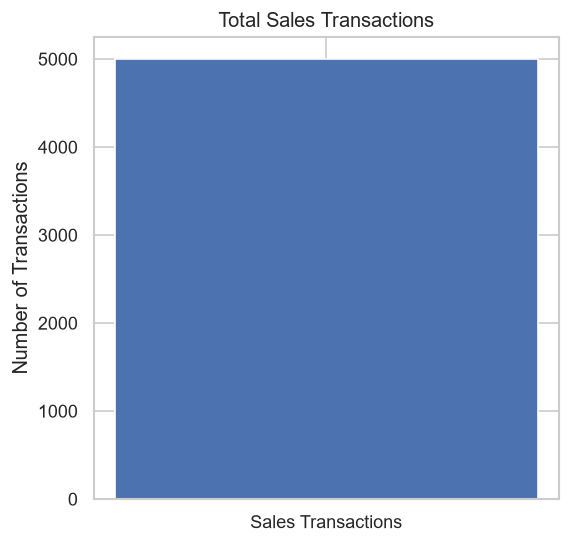

In [25]:
plt.figure(figsize=(5,5))

plt.bar(
    ["Sales Transactions"],
    [total_transactions]
)

plt.title("Total Sales Transactions")
plt.ylabel("Number of Transactions")

plt.show()

## Business Insight

The dataset contains **5000 sales transactions**, indicating the volume of business activity captured for analysis.

This metric serves as the baseline KPI for the case study and provides context for interpreting subsequent analyses. While the total number of transactions reflects the level of business activity, it does not provide information about sales revenue, profitability, or customer purchasing behavior. These aspects will be explored through more detailed analyses in the following sections.

# Question 2: How many sales transactions were processed by each store location, and how do the transaction volumes compare across different store locations?

## Business Objective

Management wants to analyze the number of sales transactions processed by each store location.

Comparing transaction volumes across stores helps identify locations with higher and lower customer activity. This information can support decisions related to staffing, inventory allocation, and operational planning.

## Code for Query

In [26]:
pipeline = [
    {
        "$group": {
            "_id": "$storeLocation",
            "Total Transactions": {"$sum": 1}
        }
    },
    {
        "$sort": {
            "Total Transactions": -1
        }
    }
]

store_transactions = list(sales.aggregate(pipeline))

store_df = pd.DataFrame(store_transactions)

store_df.rename(
    columns={
        "_id": "Store Location"
    },
    inplace=True
)

store_df

,Store Location,Total Transactions
0,Denver,1549
1,Seattle,1134
2,London,794
3,Austin,676
4,New York,501
5,San Diego,346


## Code for Visualization

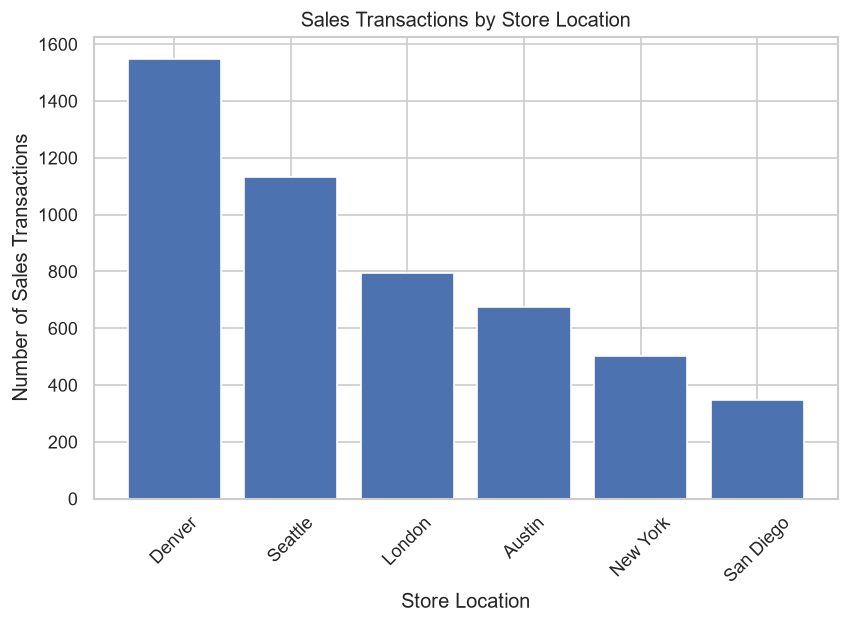

In [27]:
plt.figure(figsize=(8,5))

plt.bar(
    store_df["Store Location"],
    store_df["Total Transactions"]
)

plt.title("Sales Transactions by Store Location")
plt.xlabel("Store Location")
plt.ylabel("Number of Sales Transactions")

plt.xticks(rotation=45)

plt.show()

## Business Insight

The analysis shows that sales transactions are not evenly distributed across store locations.

- **Denver** recorded the highest number of sales transactions (**1,549**), accounting for approximately **31%** of all transactions, indicating that it is the busiest store location.
- **Seattle** (**1,134**) and **London** (**794**) also processed a substantial number of transactions, making them important contributors to the overall business.
- **Austin** (**676**) and **New York** (**501**) exhibited moderate transaction volumes.
- **San Diego** recorded the lowest number of sales transactions (**346**), suggesting comparatively lower customer activity.

The significant variation in transaction volumes across store locations indicates differences in customer demand, market size, or store performance. Store locations with higher transaction volumes may require increased inventory levels, additional staffing, and enhanced operational support to efficiently manage customer demand. Conversely, locations with lower transaction volumes may benefit from further investigation to identify potential causes, such as reduced customer footfall, local competition, or marketing effectiveness.

**Note:** This analysis evaluates the **number of sales transactions** processed by each store location. It does **not** measure sales revenue, profit, or average transaction value. Therefore, transaction volume alone should not be used to determine the overall financial performance of a store.

# Question 3: Which products have the highest total quantity sold across all sales transactions?

## Business Objective

Management wants to identify the products with the highest total quantity sold across all sales transactions.

Since a single sales transaction can contain multiple purchased products, the analysis must first separate the items stored in the `items` array before calculating the total quantity sold for each product.

Identifying high-demand products helps the business optimize inventory management, improve procurement planning, and ensure that popular products remain available to customers.

## Code for Query

In [28]:
pipeline = [
    {
        "$unwind": "$items"
    },
    {
        "$group": {
            "_id": "$items.name",
            "Total Quantity Sold": {
                "$sum": "$items.quantity"
            }
        }
    },
    {
        "$sort": {
            "Total Quantity Sold": -1
        }
    },
    {
        "$limit": 10
    }
]

product_sales = list(sales.aggregate(pipeline))

product_df = pd.DataFrame(product_sales)

product_df.rename(
    columns={
        "_id": "Product"
    },
    inplace=True
)

product_df

,Product,Total Quantity Sold
0,binder,25493
1,envelopes,25078
2,notepad,20727
3,pens,13766
4,printer paper,12092
5,backpack,6918
6,laptop,6793


## Code for Visualization

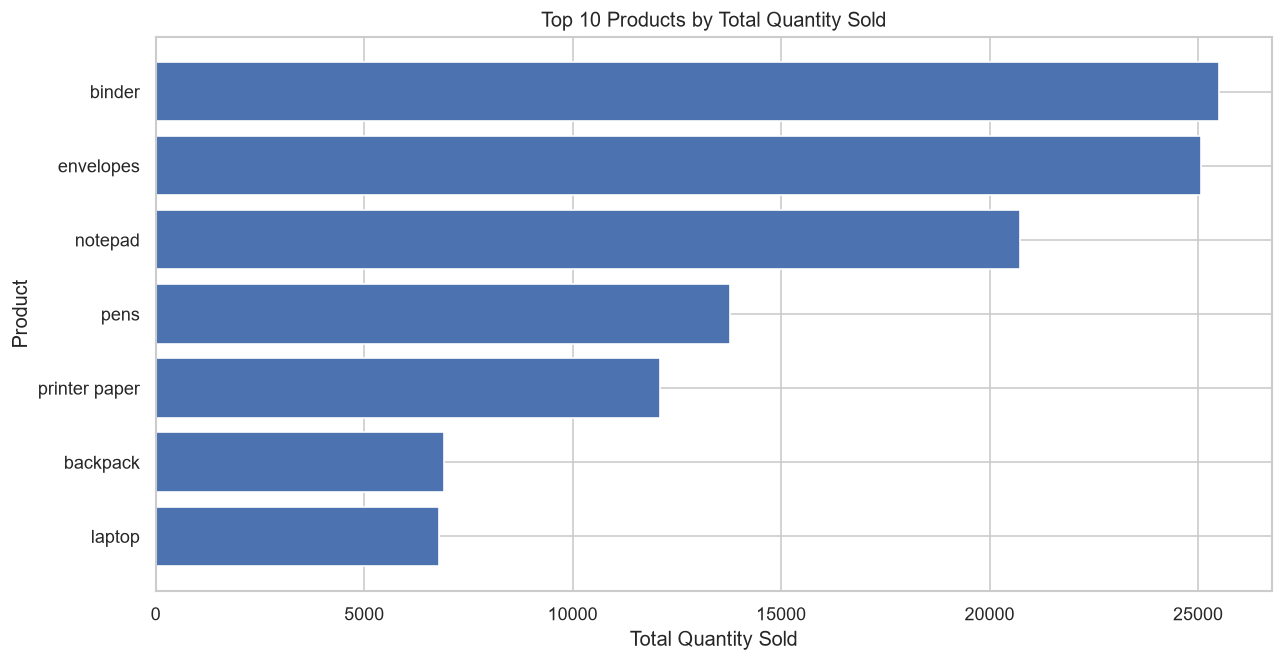

In [29]:
plt.figure(figsize=(12,6))

plt.barh(
    product_df["Product"],
    product_df["Total Quantity Sold"]
)

plt.title("Top 10 Products by Total Quantity Sold")
plt.xlabel("Total Quantity Sold")
plt.ylabel("Product")

plt.gca().invert_yaxis()

plt.show()

## Business Insight

The analysis identifies the **top-selling products based on the total quantity sold** across all sales transactions.

- **Binder** is the most frequently sold product, with a total sales quantity of **25,493** units.
- **Envelopes** (**25,078** units) and **Notepad** (**20,727** units) are also among the highest-demand products, indicating consistently strong customer demand.
- **Pens** and **Printer Paper** occupy the middle of the ranking, while **Backpack** and **Laptop** have comparatively lower quantities sold.

The results suggest that office stationery products account for a significant portion of the total sales volume. Since these products are purchased frequently, maintaining adequate inventory levels is essential to prevent stock shortages and ensure uninterrupted sales. Products with lower sales quantities may require further analysis to determine whether they are premium-priced items, seasonal products, or products with lower customer demand.

**Note:** This analysis ranks products based on the **total quantity sold** and does **not** consider product price, sales revenue, or profit margin. Therefore, products with lower sales quantities may still generate higher revenue if they have a higher selling price.

# Overall Observations

Based on the exploratory data analysis performed in this case study, the following key observations were made:

1. The dataset contains **5,000 sales transactions**, providing sufficient business data for analysis.

2. Sales transactions are unevenly distributed across store locations. **Denver** processed the highest number of transactions, while **San Diego** recorded the lowest transaction volume.

3. Product demand also varies significantly. **Binder**, **Envelopes**, and **Notepad** are the highest-selling products based on the total quantity sold, whereas products such as **Backpack** and **Laptop** recorded comparatively lower sales quantities.

These observations provide an initial understanding of customer purchasing patterns, store activity, and product demand within the retail business.

# Actionable Insights and Recommendations

Based on the observations obtained from the exploratory data analysis, the following business recommendations can be made:

## 1. Inventory Management

- Maintain higher inventory levels for high-demand products such as **Binder**, **Envelopes**, and **Notepad** to minimize stock shortages.
- Periodically review inventory for low-demand products to avoid excessive stock and reduce holding costs.

---

## 2. Store Operations

- Allocate adequate staff and operational resources to high-traffic stores, particularly **Denver** and **Seattle**, to efficiently handle customer demand.
- Investigate the reasons for lower transaction volumes in stores such as **San Diego** and identify opportunities to improve customer engagement and sales performance.

---

## 3. Sales Strategy

- Regularly monitor transaction volumes across store locations to identify changes in customer activity.
- Analyze product demand trends to support procurement planning and improve product availability.

---